<div align="center">

# ARITZIA-INSPIRED BUYER DASHBOARD
### Product Performance • Inventory • Pricing • Merchandising

</div>


**Purpose:** Demonstrate how an assistant buyer could use retail sales, inventory, pricing, markdown, seasonality, and product data to make better buying and merchandising decisions.

**Dataset:** [Retail Fashion Boutique Data – Sales Analytics 2025 (Kaggle)](https://www.kaggle.com/datasets/pratyushpuri/retail-fashion-boutique-data-sales-analytics-2025)

**Inspiration:** [Zara Sales Analysis dashboard](https://github.com/Mehdi-Benbiba/Zara-Sales-analysis/blob/main/Zara%20sales%20dashboard.pdf) — this project mirrors that single-page dashboard *layout* (KPI cards + charts + table together) while telling a *different* story (inventory/markdown/returns/ratings, since there's no sales-volume data here).


## Important Analytical Limitations

Being upfront about what this dataset can and cannot tell us:

**This dataset does NOT provide:**
- Actual sales volume
- Units sold
- Revenue
- Supplier information
- Supplier lead time
- Purchase orders
- Procurement cost
- Demand forecast

**Therefore, this dashboard does NOT claim to perform:**
- Sales forecasting
- Procurement optimization
- Demand forecasting
- Supplier optimization

**Instead, this dashboard is positioned as:**

> ### Assistant Buyer / Merchandising Decision Support

...focused specifically on **inventory, pricing, markdown, product assortment, customer ratings, and returns** — using only the fields that actually exist in the data.


### Guiding principles

1. Everything is calculated directly from the dataset — nothing is fabricated.
2. Stock Quantity is never treated as, or labeled as, sales volume.
3. All buyer recommendation rules in this notebook are an explicit **prototype / decision-support tool**, not a real retail buying methodology.
4. Return-related visuals describe *what* is happening, not *why*, since the dataset doesn't support causal claims beyond the stated `return_reason` categories.
5. The Stock Quantity vs. Markdown % scatter plot is the analytical centerpiece of this dashboard.

**Out of scope (by design):** No machine learning, demand forecasting, supplier management, purchase orders, SQL database, login system, AI chatbot, external APIs, complex optimization, or fabricated columns (e.g. fake sales or supplier data).


---


## 0. Setup

Run this cell first. If you're in Google Colab and haven't uploaded the CSV yet, uncomment the `files.upload()` block to pick it from your computer. If the CSV is already sitting next to this notebook (e.g. running locally), just leave it as-is.


In [1]:
# If running in Google Colab and you need to upload the CSV, uncomment these two lines:
# from google.colab import files
# uploaded = files.upload()  # select fashion_boutique_dataset.csv when prompted

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

CATEGORY_COLORS = {
    'Accessories': '#2C3E50', 'Bottoms': '#C0392B', 'Dresses': '#3B7DD8',
    'Outerwear': '#E6A817', 'Shoes': '#3E8E5A', 'Tops': '#8E44AD',
}

DATA_PATH = 'fashion_boutique_dataset.csv'  # update path if needed
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dataset loaded: 2,176 rows x 14 columns


## 1. Load & Inspect the Data

Confirming exact column names, types, and data quality before building any rules or charts — nothing downstream should assume a column exists that isn't actually here.


In [2]:
df.dtypes


product_id                 str
category                   str
brand                      str
season                     str
size                       str
color                      str
original_price         float64
markdown_percentage    float64
current_price          float64
purchase_date              str
stock_quantity           int64
customer_rating        float64
is_returned               bool
return_reason              str
dtype: object

In [3]:
df.head(10)


,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,2025-07-05,37,3.0,False,NaN
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,2,2.5,False,NaN
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,2025-08-06,22,4.3,False,NaN
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,2025-07-07,48,2.6,False,NaN
4,FB000005,Tops,Banana Republic,Winter,XL,Black,105.02,0.0,105.02,2025-08-06,10,NaN,False,NaN
5,FB000006,Accessories,Zara,Fall,NaN,White,35.03,35.4,22.63,2025-08-06,38,2.9,True,Color Mismatch
6,FB000007,Bottoms,Zara,Spring,S,Gray,53.83,54.5,24.49,2024-10-29,38,2.6,False,NaN
7,FB000008,Dresses,Mango,Winter,XL,Blue,91.55,22.1,71.32,2025-08-06,47,1.6,False,NaN
8,FB000009,Outerwear,Uniqlo,Spring,XL,Green,227.73,12.8,198.58,2025-03-24,14,NaN,False,NaN
9,FB000010,Outerwear,H&M,Fall,XXL,Pink,248.41,10.9,221.33,2025-08-06,37,NaN,False,NaN


In [4]:
# Null counts per column
df.isnull().sum().to_frame('null_count').assign(
    null_pct=lambda x: (x['null_count'] / len(df) * 100).round(1)
)


,null_count,null_pct
product_id,0,0.0
category,0,0.0
brand,0,0.0
season,0,0.0
size,491,22.6
color,0,0.0
original_price,0,0.0
markdown_percentage,0,0.0
current_price,0,0.0
purchase_date,0,0.0


In [5]:
# Category-type field values, to confirm exact labels used downstream
for col in ['category', 'brand', 'season', 'size']:
    print(f"{col}: {sorted(df[col].dropna().unique())}")


category: ['Accessories', 'Bottoms', 'Dresses', 'Outerwear', 'Shoes', 'Tops']
brand: ['Ann Taylor', 'Banana Republic', 'Forever21', 'Gap', 'H&M', 'Mango', 'Uniqlo', 'Zara']
season: ['Fall', 'Spring', 'Summer', 'Winter']
size: ['L', 'M', 'S', 'XL', 'XS', 'XXL']


**Data quality notes (confirmed above):**

- `size` is null for ~23% of rows (likely one-size-fits-all items like some accessories) — left as-is, not imputed.
- `customer_rating` is null for ~17% of rows. Per project decision: missing ratings are **excluded** from the buyer-recommendation rule logic (they don't count as "good" or "poor") and are **excluded** from rating-based visualizations, but the underlying rows are still included normally in KPIs and the product table.
- `is_returned` is boolean; `return_reason` is only populated when `is_returned` is `True`.
- `product_id` is unique per row (no duplicates) — each row represents one product/SKU record, not an aggregated product line.
- There is no sales-volume or units-sold column anywhere in this dataset. `stock_quantity` is inventory on hand, not units sold.


## 2. Data Preparation

Before building KPIs, the recommendation engine, or charts, we derive a few reusable fields:

- `purchase_date` parsed to an actual datetime.
- **Stock tier** (Low / Moderate / High) — split into terciles (roughly equal-sized thirds) directly from the data's own distribution.
- **Markdown tier** (Low / Moderate / High) — `0%` markdown is treated as "Low/none" (this is true for ~60% of rows), anything above the 75th percentile of markdown is "High", and everything else is "Moderate".
- **Rating tier** (Good / Neutral / Poor / Unknown) — `Good` ≥ 4.0, `Poor` ≤ 2.0, `Unknown` = missing rating (never treated as good or poor).

These tiers are used consistently across the Buyer Recommendation rules and the Buyer Attention alerts further down, so the whole dashboard applies the same definitions of "low stock" / "high markdown" / "good rating" everywhere.


In [6]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'], errors='coerce')

# --- Stock tier: terciles of stock_quantity ---
df['stock_tier'] = pd.qcut(df['stock_quantity'], 3, labels=['Low', 'Moderate', 'High'])

# --- Markdown tier: 0% = Low/none, >75th percentile = High, else Moderate ---
markdown_high_cutoff = df['markdown_percentage'].quantile(0.75)

def _markdown_tier(x, cutoff=markdown_high_cutoff):
    if x == 0:
        return 'Low'
    elif x <= cutoff:
        return 'Moderate'
    else:
        return 'High'

df['markdown_tier'] = df['markdown_percentage'].apply(_markdown_tier)

# --- Rating tier: Good >=4.0, Poor <=2.0, Unknown = missing, else Neutral ---
def _rating_tier(x):
    if pd.isna(x):
        return 'Unknown'
    elif x >= 4.0:
        return 'Good'
    elif x <= 2.0:
        return 'Poor'
    else:
        return 'Neutral'

df['rating_tier'] = df['customer_rating'].apply(_rating_tier)

print(f"Markdown 'High' cutoff (75th percentile): {markdown_high_cutoff:.1f}%")
print()
print("Stock tier counts:\n", df['stock_tier'].value_counts(), sep='')
print()
print("Markdown tier counts:\n", df['markdown_tier'].value_counts(), sep='')
print()
print("Rating tier counts:\n", df['rating_tier'].value_counts(), sep='')


Markdown 'High' cutoff (75th percentile): 22.4%

Stock tier counts:
stock_tier
Low         775
High        725
Moderate    676
Name: count, dtype: int64

Markdown tier counts:
markdown_tier
Low         1298
High         544
Moderate     334
Name: count, dtype: int64

Rating tier counts:
rating_tier
Neutral    849
Good       483
Poor       482
Unknown    362
Name: count, dtype: int64


---


## Executive Dashboard

One combined view — styled KPI cards followed by all six required charts and the Top 10 table in a single grid, mirroring the Zara reference's single-page layout.


The KPI cards and every chart below are assembled into **one matplotlib figure** and rendered with a single `plt.show()`, so the whole thing renders as one combined image — not several separate outputs stacked on top of each other.

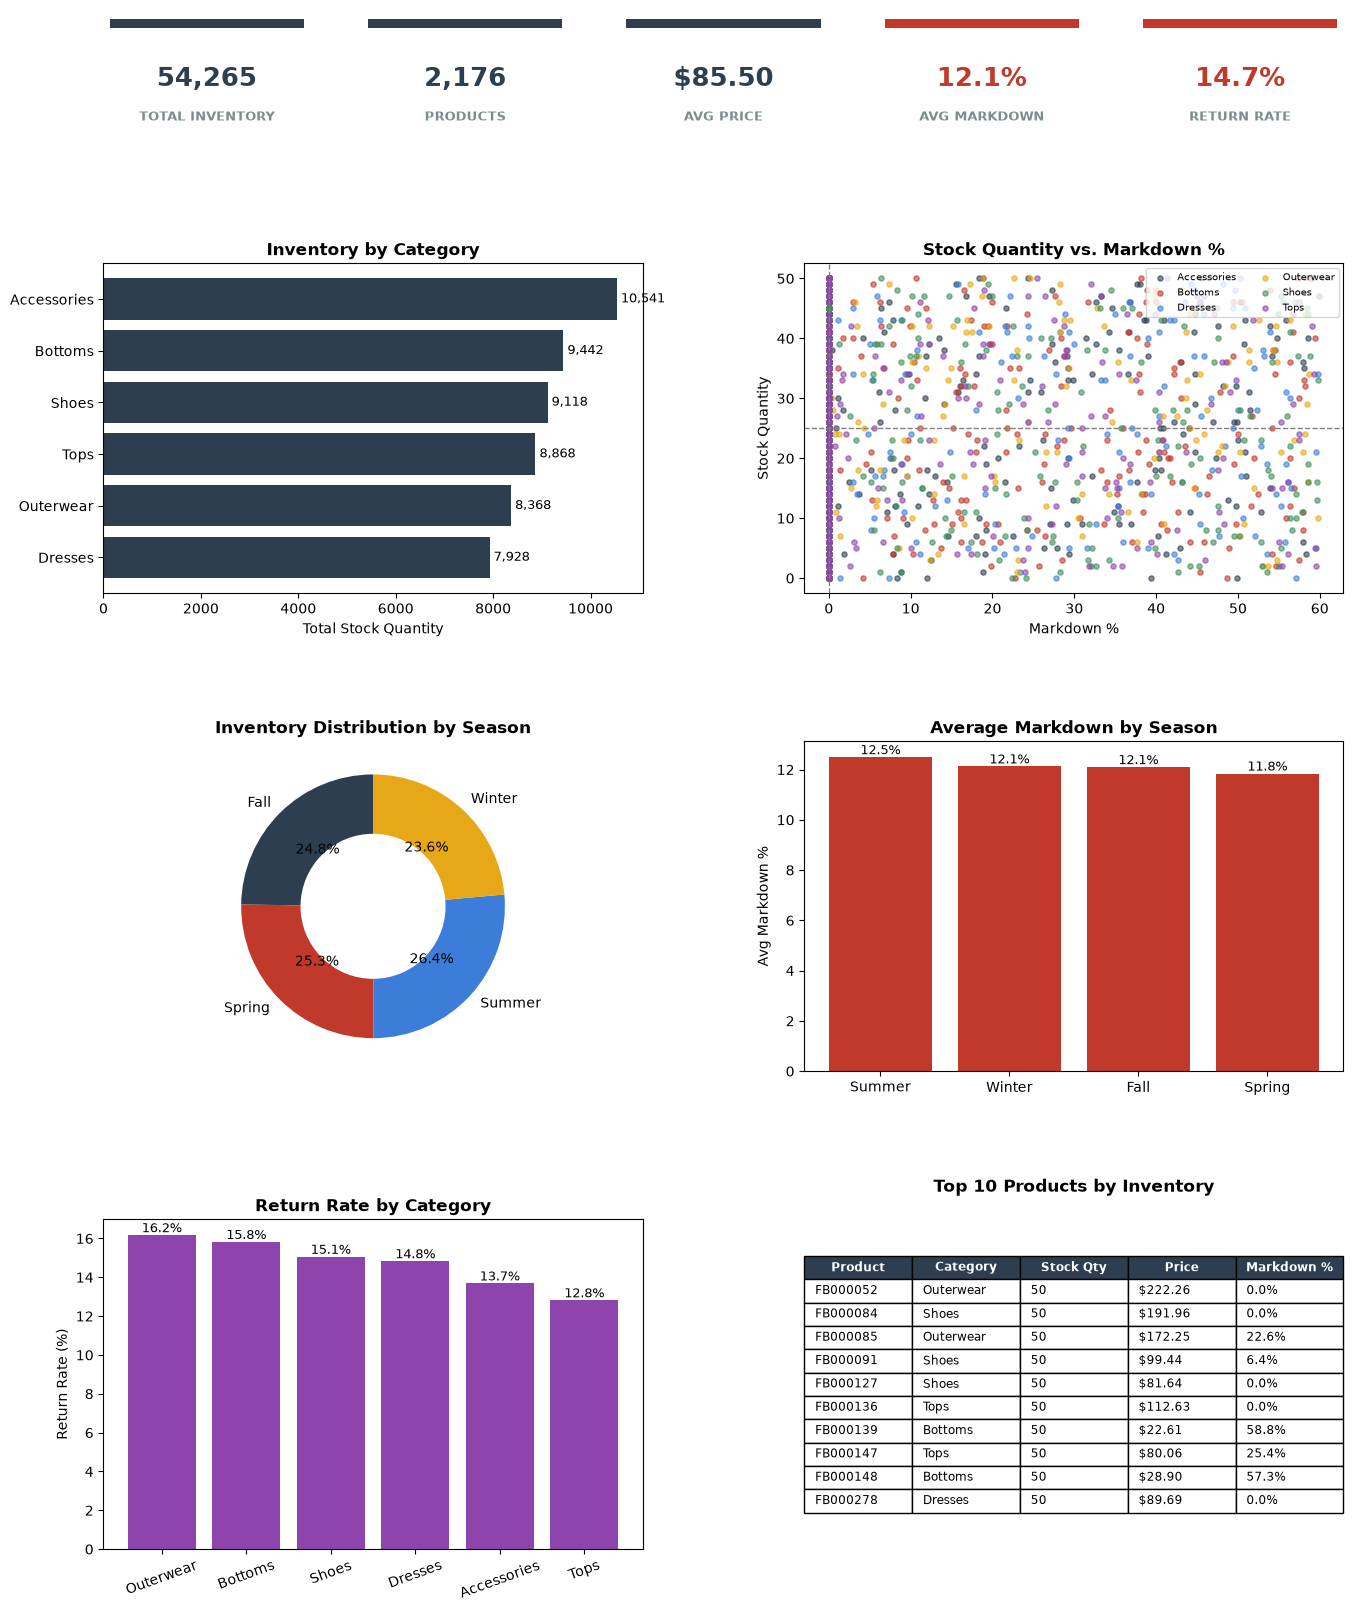

In [7]:
# ============================================================
# Everything below -- KPIs + all 6 charts + the Top 10 table --
# is assembled into ONE matplotlib figure and rendered with a
# single plt.show(), so it appears as one unified visual.
# ============================================================

# --- KPIs ---
total_inventory = int(df['stock_quantity'].sum())
total_products = int(df['product_id'].nunique())
avg_price = df['current_price'].mean()
avg_markdown = df['markdown_percentage'].mean()
return_rate = df['is_returned'].mean() * 100

kpis = [
    ('Total Inventory', f"{total_inventory:,}", '#2C3E50'),
    ('Products', f"{total_products:,}", '#2C3E50'),
    ('Avg Price', f"${avg_price:,.2f}", '#2C3E50'),
    ('Avg Markdown', f"{avg_markdown:.1f}%", '#C0392B'),
    ('Return Rate', f"{return_rate:.1f}%", '#C0392B'),
]

fig = plt.figure(figsize=(16, 20))
outer = fig.add_gridspec(2, 1, height_ratios=[0.09, 0.91], hspace=0.18)

# --- KPI row ---
kpi_gs = outer[0].subgridspec(1, 5, wspace=0.25)
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(kpi_gs[0, i])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    box = FancyBboxPatch((0.03, 0.05), 0.94, 0.9, boxstyle='round,pad=0.02,rounding_size=0.08',
                          linewidth=0, facecolor='white')
    ax.add_patch(box)
    ax.add_patch(plt.Rectangle((0.03, 0.85), 0.94, 0.07, facecolor=color, linewidth=0))
    ax.text(0.5, 0.45, value, ha='center', va='center', fontsize=19, fontweight='bold', color=color)
    ax.text(0.5, 0.15, label.upper(), ha='center', va='center', fontsize=9, color='#7f8c8d', fontweight='bold')

# --- Chart grid (3 rows x 2 cols) ---
grid_gs = outer[1].subgridspec(3, 2, hspace=0.45, wspace=0.3)

# (0,0) Inventory by Category -- horizontal bar
# Business question: Where are we carrying the most inventory?
ax1 = fig.add_subplot(grid_gs[0, 0])
inv_by_category = df.groupby('category', as_index=False)['stock_quantity'].sum().sort_values('stock_quantity')
ax1.barh(inv_by_category['category'], inv_by_category['stock_quantity'], color='#2C3E50')
for y, v in enumerate(inv_by_category['stock_quantity']):
    ax1.text(v, y, f' {v:,}', va='center', fontsize=9)
ax1.set_title('Inventory by Category', fontweight='bold')
ax1.set_xlabel('Total Stock Quantity')

# (0,1) Stock Quantity vs. Markdown % -- scatter (analytical centerpiece)
# Quadrants (dashed lines = dataset medians): high stock+high markdown = potential
# overstock/review; high stock+low markdown = monitor; low stock+low markdown =
# healthy; low stock+high markdown = investigate. Prototype lens only.
ax2 = fig.add_subplot(grid_gs[0, 1])
median_stock = df['stock_quantity'].median()
median_markdown = df['markdown_percentage'].median()
for cat, sub in df.groupby('category'):
    ax2.scatter(sub['markdown_percentage'], sub['stock_quantity'], s=14, alpha=0.6,
                color=CATEGORY_COLORS[cat], label=cat)
ax2.axvline(median_markdown, linestyle='--', color='gray', linewidth=1)
ax2.axhline(median_stock, linestyle='--', color='gray', linewidth=1)
ax2.set_title('Stock Quantity vs. Markdown %', fontweight='bold')
ax2.set_xlabel('Markdown %'); ax2.set_ylabel('Stock Quantity')
ax2.legend(fontsize=7, loc='upper right', ncol=2)

# (1,0) Inventory Distribution by Season -- donut
ax3 = fig.add_subplot(grid_gs[1, 0])
inv_by_season = df.groupby('season', as_index=False)['stock_quantity'].sum()
ax3.pie(inv_by_season['stock_quantity'], labels=inv_by_season['season'], autopct='%1.1f%%',
        wedgeprops=dict(width=0.45), startangle=90,
        colors=['#2C3E50', '#C0392B', '#3B7DD8', '#E6A817'])
ax3.set_title('Inventory Distribution by Season', fontweight='bold')

# (1,1) Average Markdown by Season -- bar
ax4 = fig.add_subplot(grid_gs[1, 1])
markdown_by_season = df.groupby('season', as_index=False)['markdown_percentage'].mean().sort_values('markdown_percentage', ascending=False)
ax4.bar(markdown_by_season['season'], markdown_by_season['markdown_percentage'], color='#C0392B')
for x, v in enumerate(markdown_by_season['markdown_percentage']):
    ax4.text(x, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax4.set_title('Average Markdown by Season', fontweight='bold')
ax4.set_ylabel('Avg Markdown %')

# (2,0) Return Rate by Category -- bar
ax5 = fig.add_subplot(grid_gs[2, 0])
return_rate_by_category = df.groupby('category', as_index=False)['is_returned'].mean()
return_rate_by_category['return_rate_pct'] = return_rate_by_category['is_returned'] * 100
return_rate_by_category = return_rate_by_category.sort_values('return_rate_pct', ascending=False)
ax5.bar(return_rate_by_category['category'], return_rate_by_category['return_rate_pct'], color='#8E44AD')
for x, v in enumerate(return_rate_by_category['return_rate_pct']):
    ax5.text(x, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax5.set_title('Return Rate by Category', fontweight='bold')
ax5.set_ylabel('Return Rate (%)')
ax5.tick_params(axis='x', rotation=20)

# (2,1) Top 10 Products by Inventory -- table
# NOTE: this dataset has no sales-volume data, so these are never labeled "best
# sellers" (unlike the Zara reference) -- they are simply the highest on-hand stock.
ax6 = fig.add_subplot(grid_gs[2, 1])
ax6.axis('off')
top10_cols = ['product_id', 'category', 'stock_quantity', 'current_price', 'markdown_percentage']
top10_inventory = df.nlargest(10, 'stock_quantity')[top10_cols]
table_rows = [[pid, cat, f'{sq:,}', f'${p:,.2f}', f'{m:.1f}%']
              for pid, cat, sq, p, m in top10_inventory.itertuples(index=False)]
tbl = ax6.table(cellText=table_rows,
                 colLabels=['Product', 'Category', 'Stock Qty', 'Price', 'Markdown %'],
                 loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
ax6.set_title('Top 10 Products by Inventory', fontweight='bold', pad=20)

plt.show()


_Quadrant guide for the Stock Quantity vs. Markdown % chart above:_
- **High stock + high markdown** → potential overstock / review
- **High stock + low markdown** → monitor inventory
- **Low stock + low markdown** → potentially healthy product
- **Low stock + high markdown** → investigate

*These quadrants are a prototype lens for exploration, not a claim about any retailer's actual buying rules.*


---


## Buyer Recommendations (Rule-Based Prototype)

> ⚠️ **This is an illustrative, rule-based prototype only** — not Aritzia's (or any retailer's) actual buying methodology. It is a decision-support demo built purely from the tiers defined in §2.

| Flag | Criteria |
|---|---|
| 🔥 **BUY / PRIORITIZE** | Low stock tier **and** Low markdown tier **and** Good rating tier |
| 🛑 **HOLD / REVIEW** | High stock tier **and** High markdown tier **and** (Poor rating tier **or** returned) |
| 👀 **MONITOR** | Everything else (the default / moderate case) |

Rows with an `Unknown` rating tier (missing `customer_rating`) can never qualify for `BUY` (which requires a confirmed Good rating), but can still be flagged `HOLD` if stock/markdown are both high and the item was returned.


In [8]:
def buyer_recommendation(row):
    if row['stock_tier'] == 'Low' and row['markdown_tier'] == 'Low' and row['rating_tier'] == 'Good':
        return '🔥 BUY / PRIORITIZE'
    if row['stock_tier'] == 'High' and row['markdown_tier'] == 'High' and (
        row['rating_tier'] == 'Poor' or row['is_returned'] == True
    ):
        return '🛑 HOLD / REVIEW'
    return '👀 MONITOR'

df['buyer_recommendation'] = df.apply(buyer_recommendation, axis=1)

rec_counts = df['buyer_recommendation'].value_counts()
rec_pct = df['buyer_recommendation'].value_counts(normalize=True).mul(100).round(1)

pd.DataFrame({'Count': rec_counts, 'Share of Products': rec_pct.astype(str) + '%'})


,Count,Share of Products
buyer_recommendation,,
👀 MONITOR,2010,92.4%
🔥 BUY / PRIORITIZE,105,4.8%
🛑 HOLD / REVIEW,61,2.8%


## Product Performance Table

Per-product view including the rule-based Buyer Recommendation above.


In [9]:
product_performance = df[[
    'product_id', 'category', 'brand', 'current_price', 'stock_quantity',
    'markdown_percentage', 'customer_rating', 'buyer_recommendation'
]].rename(columns={
    'product_id': 'Product',
    'category': 'Category',
    'brand': 'Brand',
    'current_price': 'Current Price',
    'stock_quantity': 'Stock Quantity',
    'markdown_percentage': 'Markdown %',
    'customer_rating': 'Rating',
    'buyer_recommendation': 'Buyer Recommendation'
})

print(f"Full table: {len(product_performance):,} products")
product_performance.head(20)


Full table: 2,176 products


,Product,Category,Brand,Current Price,Stock Quantity,Markdown %,Rating,Buyer Recommendation
0,FB000001,Outerwear,Zara,196.01,37,0.0,3.0,👀 MONITOR
1,FB000002,Tops,Uniqlo,119.64,2,0.0,2.5,👀 MONITOR
2,FB000003,Accessories,Uniqlo,33.80,22,0.0,4.3,👀 MONITOR
3,FB000004,Shoes,Uniqlo,75.36,48,0.0,2.6,👀 MONITOR
4,FB000005,Tops,Banana Republic,105.02,10,0.0,NaN,👀 MONITOR
5,FB000006,Accessories,Zara,22.63,38,35.4,2.9,🛑 HOLD / REVIEW
6,FB000007,Bottoms,Zara,24.49,38,54.5,2.6,👀 MONITOR
7,FB000008,Dresses,Mango,71.32,47,22.1,1.6,👀 MONITOR
8,FB000009,Outerwear,Uniqlo,198.58,14,12.8,NaN,👀 MONITOR
9,FB000010,Outerwear,H&M,221.33,37,10.9,NaN,👀 MONITOR


_The full `product_performance` DataFrame contains all 2,176 rows and can be exported (e.g. `product_performance.to_csv('product_performance.csv', index=False)`) — only the first 20 rows are shown above to keep the notebook readable._

---


## Detailed Analysis — Chart by Chart

The Executive Dashboard above gives the at-a-glance view. This section walks through each chart individually, standalone, with a short data-driven read underneath — so we can build up a narrative rather than just look at pictures.


### 1. Inventory by Category

**Business question:** *Where are we carrying the most inventory?*


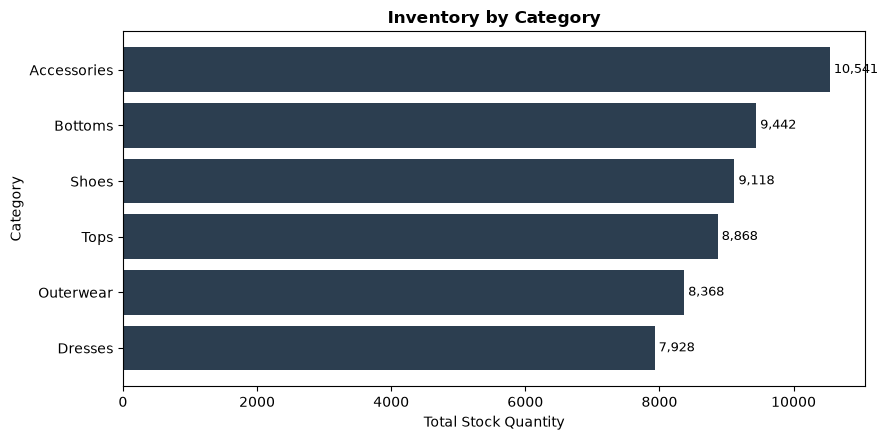

In [10]:
inv_by_category_full = df.groupby('category', as_index=False)['stock_quantity'].sum() \
    .sort_values('stock_quantity', ascending=True)

fig1, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.barh(inv_by_category_full['category'], inv_by_category_full['stock_quantity'], color='#2C3E50')
for y, v in enumerate(inv_by_category_full['stock_quantity']):
    ax1.text(v, y, f' {v:,}', va='center', fontsize=9)
ax1.set_title('Inventory by Category', fontweight='bold')
ax1.set_xlabel('Total Stock Quantity'); ax1.set_ylabel('Category')
plt.tight_layout()
plt.show()


**What this tells us:** Accessories carries the most inventory (10,541 units), Dresses the least (7,928). The spread across all six categories is fairly narrow — top to bottom is only about a 33% difference — so no single category is dramatically over- or under-stocked relative to the others at the category level. Any overstock concerns are more likely to show up at the individual-product level (see the scatter plot next) than as a category-wide imbalance.


### 2. Stock Quantity vs. Markdown % — the analytical centerpiece

**Business question:** *Identify potential relationships between inventory levels and markdowns.*

Quadrant guide (dashed lines = dataset medians):
- High stock + high markdown → potential overstock / review
- High stock + low markdown → monitor inventory
- Low stock + low markdown → potentially healthy product
- Low stock + high markdown → investigate

*These quadrants are a prototype lens for exploration, not a claim about any retailer's actual buying rules.*


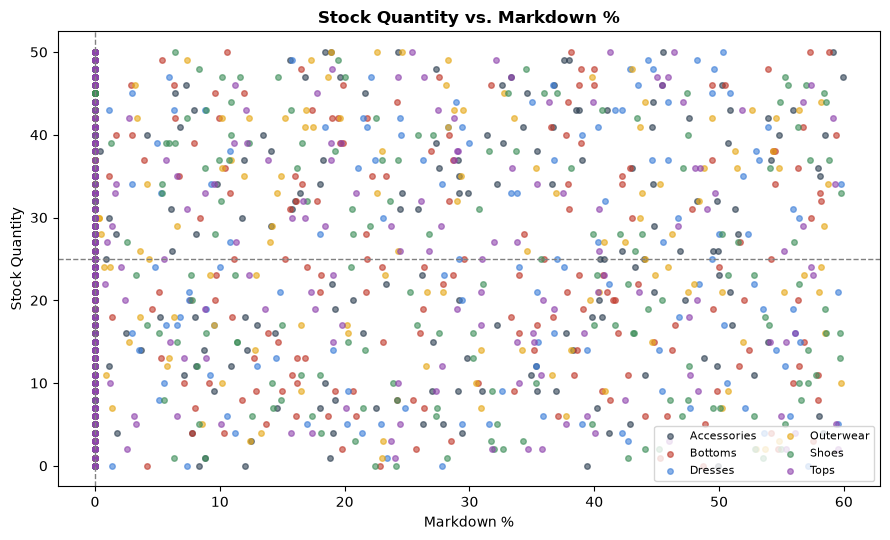

Correlation between stock quantity and markdown %: 0.012


In [11]:
median_stock = df['stock_quantity'].median()
median_markdown = df['markdown_percentage'].median()

fig2, ax2 = plt.subplots(figsize=(9, 5.5))
for cat, sub in df.groupby('category'):
    ax2.scatter(sub['markdown_percentage'], sub['stock_quantity'], s=16, alpha=0.6,
                color=CATEGORY_COLORS[cat], label=cat)
ax2.axvline(median_markdown, linestyle='--', color='gray', linewidth=1)
ax2.axhline(median_stock, linestyle='--', color='gray', linewidth=1)
ax2.set_title('Stock Quantity vs. Markdown %', fontweight='bold')
ax2.set_xlabel('Markdown %'); ax2.set_ylabel('Stock Quantity')
ax2.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

corr = df['stock_quantity'].corr(df['markdown_percentage'])
print(f"Correlation between stock quantity and markdown %: {corr:.3f}")


**What this tells us:** The correlation between stock quantity and markdown % is essentially zero (r ≈ 0.01) — and the four quadrants come out fairly balanced (423 products high-stock/high-markdown, 639 high-stock/low-markdown, 659 low-stock/low-markdown, 455 low-stock/high-markdown). In other words, **high inventory does not reliably predict heavy markdown in this dataset** — markdowns appear to be applied somewhat independently of how much stock is on hand. That's a useful, honest finding in itself: it means overstock reviews need to be done product-by-product (as the Buyer Recommendations rules do), not assumed from category or seasonal averages alone.


### 3. Inventory Distribution by Season

**Business question:** *Which seasons represent the largest share of our inventory?*


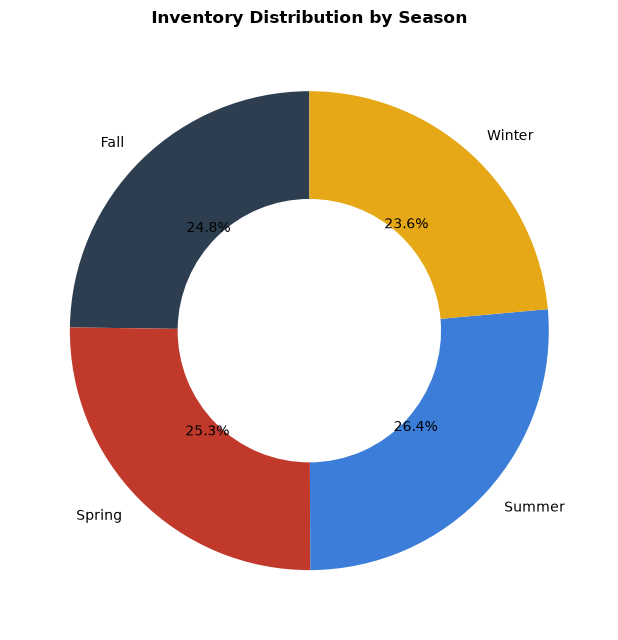

In [12]:
inv_by_season_full = df.groupby('season', as_index=False)['stock_quantity'].sum()

fig3, ax3 = plt.subplots(figsize=(6.5, 6.5))
ax3.pie(inv_by_season_full['stock_quantity'], labels=inv_by_season_full['season'], autopct='%1.1f%%',
        wedgeprops=dict(width=0.45), startangle=90,
        colors=['#2C3E50', '#C0392B', '#3B7DD8', '#E6A817'])
ax3.set_title('Inventory Distribution by Season', fontweight='bold')
plt.tight_layout()
plt.show()


**What this tells us:** Inventory is spread fairly evenly across seasons — Summer holds the largest share at 26.4%, Winter the smallest at 23.6%. A roughly 3-point spread across four seasons suggests no single season is being over- or under-stocked relative to the others; buying appears reasonably balanced across the seasonal calendar in this dataset.


### 4. Average Markdown by Season

**Business question:** *Which seasons are relying most heavily on markdowns?*


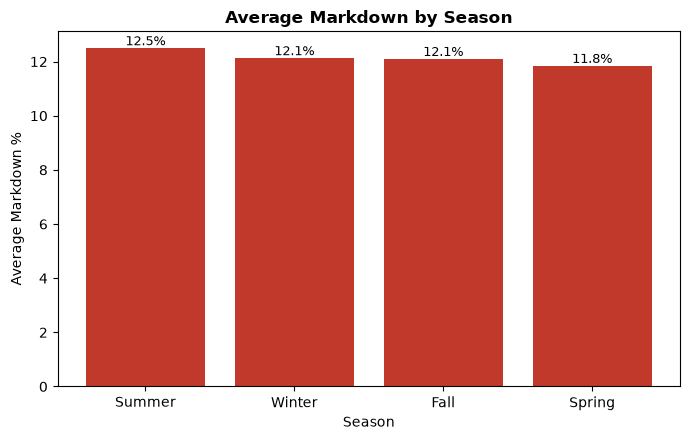

In [13]:
markdown_by_season_full = df.groupby('season', as_index=False)['markdown_percentage'].mean() \
    .sort_values('markdown_percentage', ascending=False)

fig4, ax4 = plt.subplots(figsize=(7, 4.5))
ax4.bar(markdown_by_season_full['season'], markdown_by_season_full['markdown_percentage'], color='#C0392B')
for x, v in enumerate(markdown_by_season_full['markdown_percentage']):
    ax4.text(x, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax4.set_title('Average Markdown by Season', fontweight='bold')
ax4.set_xlabel('Season'); ax4.set_ylabel('Average Markdown %')
plt.tight_layout()
plt.show()


**What this tells us:** Markdown reliance is also fairly flat across seasons — Summer is highest at 12.5%, Spring lowest at 11.8%, a narrow 0.65-point range. Combined with the Viz #3 finding, neither inventory levels nor markdown intensity swing dramatically by season in this dataset — the seasonal picture here is one of consistency rather than a standout problem season.


### 5. Return Rate by Category

**Business question:** *Are certain categories experiencing more returns?* This describes *what* is happening — it does not attempt to explain *why*, since that would go beyond what the data supports.


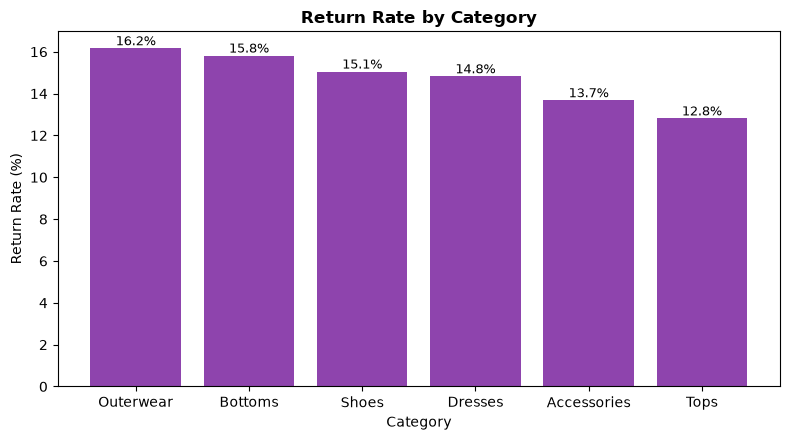

In [14]:
return_rate_by_category_full = df.groupby('category', as_index=False)['is_returned'].mean()
return_rate_by_category_full['return_rate_pct'] = return_rate_by_category_full['is_returned'] * 100
return_rate_by_category_full = return_rate_by_category_full.sort_values('return_rate_pct', ascending=False)

fig5, ax5 = plt.subplots(figsize=(8, 4.5))
ax5.bar(return_rate_by_category_full['category'], return_rate_by_category_full['return_rate_pct'], color='#8E44AD')
for x, v in enumerate(return_rate_by_category_full['return_rate_pct']):
    ax5.text(x, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax5.set_title('Return Rate by Category', fontweight='bold')
ax5.set_xlabel('Category'); ax5.set_ylabel('Return Rate (%)')
plt.tight_layout()
plt.show()


**What this tells us:** Outerwear has the highest return rate at 16.2%, Tops the lowest at 12.8% — a real but moderate gap (Outerwear returns about 26% more often, relatively speaking, than Tops). This is worth a category-level "Review product/return patterns" flag (see Buyer Attention below), but the dataset's `return_reason` field doesn't tell us *why* Outerwear returns more, so no causal claim is made here — only the pattern itself.


### 6. Top 10 Products by Inventory

⚠️ This replaces the "Top 10 Best Sellers" concept from the Zara dashboard. **This dataset has no sales-volume data**, so these are never labeled "best sellers" — they are simply the products currently holding the most inventory.


In [15]:
top10_cols_full = ['product_id', 'category', 'brand', 'stock_quantity', 'current_price', 'markdown_percentage']
top10_inventory_full = df.nlargest(10, 'stock_quantity')[top10_cols_full].rename(columns={
    'product_id': 'Product', 'category': 'Category', 'brand': 'Brand',
    'stock_quantity': 'Stock Quantity', 'current_price': 'Current Price', 'markdown_percentage': 'Markdown %'
}).reset_index(drop=True)
top10_inventory_full.index = top10_inventory_full.index + 1

max_stock_count = (df['stock_quantity'] == df['stock_quantity'].max()).sum()
print(f"Note: {max_stock_count} products are tied at the dataset's maximum stock quantity "
      f"({int(df['stock_quantity'].max())} units) — the 10 shown below are a sample of that tie group, "
      f"not a strict unique ranking.")
top10_inventory_full


Note: 42 products are tied at the dataset's maximum stock quantity (50 units) — the 10 shown below are a sample of that tie group, not a strict unique ranking.


,Product,Category,Brand,Stock Quantity,Current Price,Markdown %
1,FB000052,Outerwear,Forever21,50,222.26,0.0
2,FB000084,Shoes,Zara,50,191.96,0.0
3,FB000085,Outerwear,Ann Taylor,50,172.25,22.6
4,FB000091,Shoes,Uniqlo,50,99.44,6.4
5,FB000127,Shoes,Ann Taylor,50,81.64,0.0
6,FB000136,Tops,Gap,50,112.63,0.0
7,FB000139,Bottoms,Zara,50,22.61,58.8
8,FB000147,Tops,Zara,50,80.06,25.4
9,FB000148,Bottoms,Banana Republic,50,28.90,57.3
10,FB000278,Dresses,Zara,50,89.69,0.0


**What this tells us:** All 10 products shown sit at the dataset's maximum stock quantity (50 units) — and they're not alone: 42 products across the catalog are tied at that same maximum. Zara (4 of 10 shown) and the Shoes category (3 of 10) appear most often in this particular sample, but because so many products share the max value, this table is best read as "these are among the most heavily stocked items," not a precise top-10 ranking.


---


## Buyer Attention

Rule-based, **not AI-generated** — every alert below is calculated directly from the dataset using the same tiers defined earlier. Language is deliberately hedged: these are prompts to review, not purchasing decisions.


In [16]:
alerts = []

# --- Overstock Review: high stock tier AND high markdown tier ---
overstock = df[(df['stock_tier'] == 'High') & (df['markdown_tier'] == 'High')]
alerts.append({
    'Alert': 'Overstock Review',
    'Trigger': 'High stock quantity + high markdown %',
    'Products flagged': len(overstock),
    'Recommendation': 'Review for potential overstock.'
})

# --- Markdown Review: categories whose average markdown % exceeds the overall average ---
overall_avg_markdown = df['markdown_percentage'].mean()
cat_markdown = df.groupby('category')['markdown_percentage'].mean().sort_values(ascending=False)
flagged_markdown_categories = cat_markdown[cat_markdown > overall_avg_markdown]
alerts.append({
    'Alert': 'Markdown Review',
    'Trigger': f'Category avg markdown % above overall average ({overall_avg_markdown:.1f}%)',
    'Products flagged': ', '.join(f"{cat} ({val:.1f}%)" for cat, val in flagged_markdown_categories.items()),
    'Recommendation': 'Review markdown strategy.'
})

# --- Return Review: categories whose return rate exceeds the overall return rate ---
overall_return_rate = df['is_returned'].mean() * 100
cat_return = df.groupby('category')['is_returned'].mean().mul(100).sort_values(ascending=False)
flagged_return_categories = cat_return[cat_return > overall_return_rate]
alerts.append({
    'Alert': 'Return Review',
    'Trigger': f'Category return rate above overall rate ({overall_return_rate:.1f}%)',
    'Products flagged': ', '.join(f"{cat} ({val:.1f}%)" for cat, val in flagged_return_categories.items()),
    'Recommendation': 'Review product/return patterns.'
})

# --- Low Inventory: products in the Low stock tier ---
low_inventory = df[df['stock_tier'] == 'Low']
alerts.append({
    'Alert': 'Low Inventory',
    'Trigger': 'Stock quantity in bottom tercile',
    'Products flagged': len(low_inventory),
    'Recommendation': 'Monitor availability.'
})

alerts_df = pd.DataFrame(alerts)
alerts_df


,Alert,Trigger,Products flagged,Recommendation
0,Overstock Review,High stock quantity + high markdown %,188,Review for potential overstock.
1,Markdown Review,Category avg markdown % above overall average ...,"Bottoms (13.2%), Dresses (13.2%), Shoes (13.0%)",Review markdown strategy.
2,Return Review,Category return rate above overall rate (14.7%),"Outerwear (16.2%), Bottoms (15.8%), Shoes (15....",Review product/return patterns.
3,Low Inventory,Stock quantity in bottom tercile,775,Monitor availability.


---


## Optional: Price vs. Customer Rating

Rows with a missing `customer_rating` are excluded from this chart only (they carry no rating information to plot), consistent with the earlier decision to keep rating-based visuals limited to rated products.

- **High price + high rating** → potential premium performer
- **Low price + high rating** → potential value opportunity
- **High price + low rating** → review
- **Low price + low rating** → potentially weak product


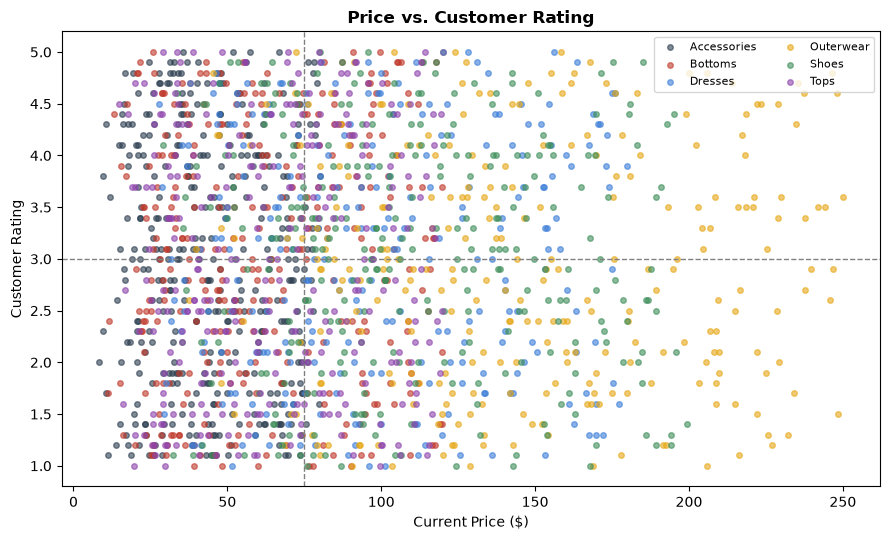

Correlation between price and rating: 0.00002
Note: 362 of 2176 rows excluded from this chart (missing rating).


In [17]:
rated_df = df.dropna(subset=['customer_rating'])
median_price = rated_df['current_price'].median()
median_rating = rated_df['customer_rating'].median()

fig7, ax7 = plt.subplots(figsize=(9, 5.5))
for cat, sub in rated_df.groupby('category'):
    ax7.scatter(sub['current_price'], sub['customer_rating'], s=16, alpha=0.6,
                color=CATEGORY_COLORS[cat], label=cat)
ax7.axvline(median_price, linestyle='--', color='gray', linewidth=1)
ax7.axhline(median_rating, linestyle='--', color='gray', linewidth=1)
ax7.set_title('Price vs. Customer Rating', fontweight='bold')
ax7.set_xlabel('Current Price ($)'); ax7.set_ylabel('Customer Rating')
ax7.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

corr7 = rated_df['current_price'].corr(rated_df['customer_rating'])
print(f"Correlation between price and rating: {corr7:.5f}")
print(f"Note: {df['customer_rating'].isnull().sum()} of {len(df)} rows excluded from this chart (missing rating).")


**What this tells us:** The correlation between price and customer rating is effectively zero (r ≈ 0.00002) — there's no evidence in this dataset that pricier items are rated any better or worse than cheaper ones. Premium performers, value opportunities, and weak products all appear to be scattered across every price point rather than clustered by price tier, so price alone isn't a useful signal for predicting customer satisfaction here.


---


## Summary

This notebook is positioned as **Assistant Buyer / Merchandising Decision Support** — not sales forecasting, procurement optimization, demand forecasting, or supplier optimization, none of which this data can support.

It builds, in order:

1. **Executive Dashboard** — styled KPI cards + all 6 required charts + Top 10 table, combined in a single dashboard card
2. **Buyer Recommendations** — rule-based prototype flag per product
3. **Product Performance Table** — full per-product view with recommendations
4. **Detailed Analysis** — each chart revisited standalone with a data-driven narrative underneath, building up the story chart by chart
5. **Buyer Attention Panel** — 4 rule-based alerts, calculated directly from the data
6. **Optional** — Price vs. Customer Rating chart, with its own narrative

**The overall narrative:** this dataset shows a fairly balanced, low-drama picture — inventory and markdown intensity are both spread evenly across seasons and categories, and stock quantity, markdown %, price, and rating show essentially no linear relationships with each other. The most actionable signals are the return-rate gap between Outerwear and Tops, and the individual products flagged by the rule-based Buyer Recommendations, rather than any sweeping category- or season-level pattern.

All numbers are calculated directly from `fashion_boutique_dataset.csv` — nothing is fabricated, and stock quantity is never presented or implied as sales volume. The buyer-recommendation and alert rules are an explicit prototype for decision-support demonstration purposes only.
